# CONUS Teacher-forcing tests

In [1]:
import os
import sys
import yaml
import argparse
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr

sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [2]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [3]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [4]:
need_publish = False

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

## Prep data

In [5]:
ds = xr.open_zarr('/glade/campaign/ral/hap/ksha/GWC_results/FINAL_run/teacher/TF_case_summary.zarr')
dict_plot = {var: da.data for var, da in ds.data_vars.items()}

In [6]:
static_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/static/C404_GP_static.zarr'
ds_static = xr.open_zarr(static_name)
lon_WRF = ds_static['XLONG'].values
lat_WRF = ds_static['XLAT'].values

## Plot

In [7]:
scale_param = '50m'

PROVINCE = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale=scale_param,
    facecolor='none')

def map_gridline_opt(ax):
    '''
    Customize cartopy map gridlines
    '''
    # lat/lon gridlines and labeling
    # GL = ax.gridlines(crs=ccrs.PlateCarree(), 
    #                   draw_labels=False, x_inline=False, y_inline=False, 
    #                   color='k', linewidth=0.1, linestyle=':', zorder=5)
    # GL.top_labels = None; GL.bottom_labels = None
    # GL.right_labels = None; GL.left_labels = None
    # GL.xlabel_style = {'size': 14}; GL.ylabel_style = {'size': 14}
    # GL.rotate_labels = False
    ax.add_feature(cfeature.BORDERS.with_scale(scale_param), linestyle='-', linewidth=1.5, zorder=7)
    ax.add_feature(PROVINCE, edgecolor='k', linestyle='-', linewidth=1.5, zorder=7)
    ax.add_feature(cfeature.COASTLINE.with_scale(scale_param ), edgecolor='k', linewidth=1.5, zorder=5)
    ax.spines['geo'].set_linewidth(2.5)
    return ax

In [8]:
fig_dir = '/glade/u/home/ksha/CONUS-404-prep/figures/'

/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/dask/array/core.py:1744: FutureWarning: The `numpy.column_stack` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(
/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/dask/array/core.py:1744: FutureWarning: The `numpy.column_stack` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(
/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/dask/array/core.py:1744: FutureWarning: The `numpy.column_stack` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.w

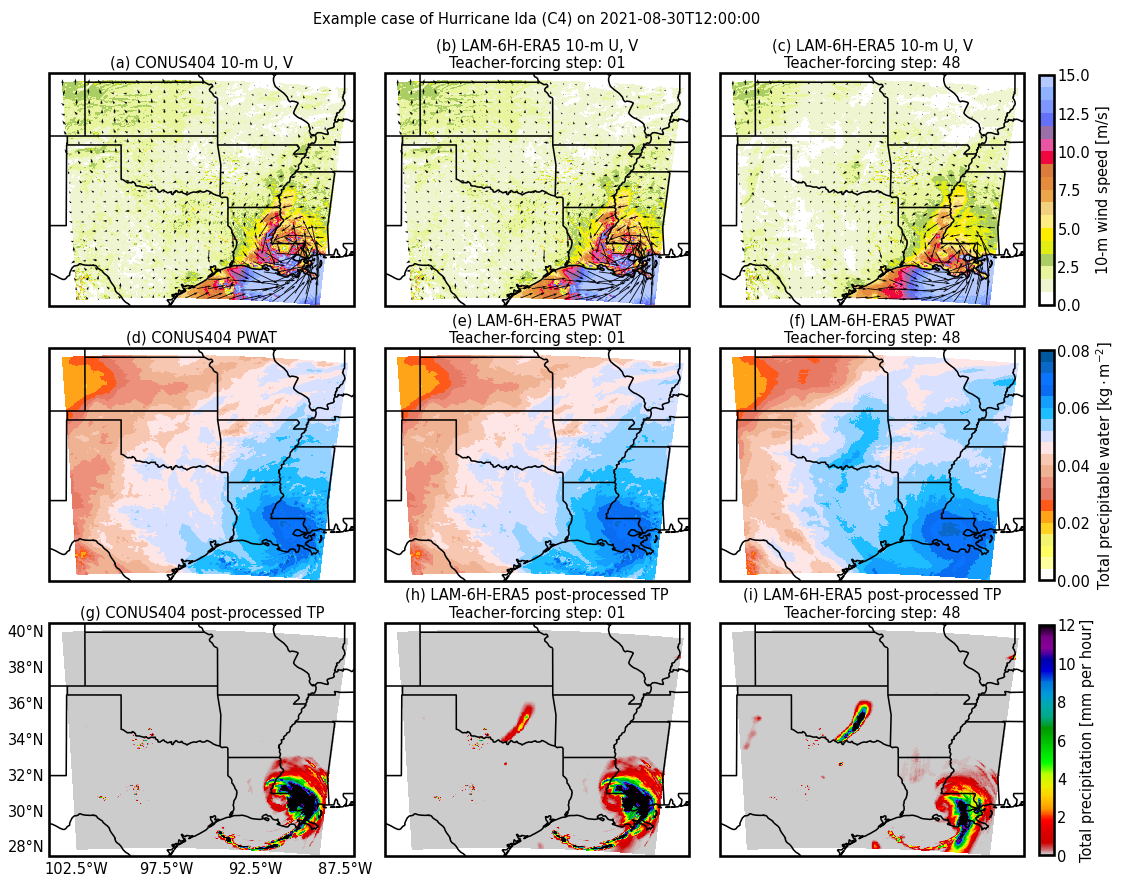

In [9]:
skip = slice(None, None, 15)

LIM_pwat = [0, 0.08] #[291, 310]
LIM_spd = [0, 15]
LIM_precip = [0, 12]

cmap_pwat = cmaps.rh_19lev #t2m_29lev
cmap_spd = cmaps.wind_17lev
cmap_precip = plt.cm.nipy_spectral_r
# gu.precip_cmap(return_rgb=True, land_map=False)

proj_ = ccrs.PlateCarree()
map_extent = [-104, -87, 27.5, 40.5]

fig = plt.figure(figsize=(13, 11), dpi=dpi_)
gs = gridspec.GridSpec(3, 3)

AX_maps = []
# GL_maps = []
AX_maps.append(plt.subplot(gs[0, 0], projection=proj_))
AX_maps.append(plt.subplot(gs[0, 1], projection=proj_))
AX_maps.append(plt.subplot(gs[0, 2], projection=proj_))
AX_maps.append(plt.subplot(gs[1, 0], projection=proj_))
AX_maps.append(plt.subplot(gs[1, 1], projection=proj_))
AX_maps.append(plt.subplot(gs[1, 2], projection=proj_))
AX_maps.append(plt.subplot(gs[2, 0], projection=proj_))
AX_maps.append(plt.subplot(gs[2, 1], projection=proj_))
AX_maps.append(plt.subplot(gs[2, 2], projection=proj_))

plt.subplots_adjust(0, 0, 1, 1, hspace=0, wspace=0.1)

for ax in AX_maps:
    ax.set_extent(map_extent, crs=proj_)
    ax = map_gridline_opt(ax)

i_ax = 6
ax = AX_maps[i_ax]
    
GL = ax.gridlines(
    crs=ccrs.PlateCarree(), 
    draw_labels=True, x_inline=False, y_inline=False, 
    color=None, linewidth=0, zorder=5
)

GL.xlabel_style = {'size': 14}
GL.ylabel_style = {'size': 14}

GL.top_labels = None
# GL.left_labels = None
# GL.bottom_labels = None
GL.right_labels = None

# =================================================== #

for i_n, name in enumerate(['target', 'TF01', 'TF48']):
    
    CS1 = AX_maps[i_n].pcolormesh(
        lon_WRF, lat_WRF, dict_plot[f'{name}_spd'], 
        vmin=LIM_spd[0], vmax=LIM_spd[1], cmap=cmap_spd, transform=ccrs.PlateCarree()
    )
    
    AX_maps[i_n].quiver(
        lon_WRF[skip, skip], lat_WRF[skip, skip], 
        dict_plot[f'{name}_U10'][skip, skip], dict_plot[f'{name}_V10'][skip, skip],
        color='k', scale=150, transform=ccrs.PlateCarree()
    )


    CS2 = AX_maps[3+i_n].pcolormesh(
        lon_WRF, lat_WRF, dict_plot[f'{name}_PWAT'],
        vmin=LIM_pwat[0], vmax=LIM_pwat[1], cmap=cmap_pwat, transform=ccrs.PlateCarree()
    )
    
    CS3 = AX_maps[6+i_n].pcolormesh(
        lon_WRF, lat_WRF, dict_plot[f'{name}_precip'],
        vmin=LIM_precip[0], vmax=LIM_precip[1], cmap=cmap_precip, transform=ccrs.PlateCarree()
    )
    
time_valid = '2021-08-30T12:00:00'

AX_maps[0].set_title('(a) CONUS404 10-m U, V', fontsize=14)
AX_maps[1].set_title('(b) LAM-6H-ERA5 10-m U, V\nTeacher-forcing step: 01', fontsize=14)
AX_maps[2].set_title('(c) LAM-6H-ERA5 10-m U, V\nTeacher-forcing step: 48', fontsize=14)

AX_maps[3].set_title('(d) CONUS404 PWAT'.format(time_valid), fontsize=14)
AX_maps[4].set_title('(e) LAM-6H-ERA5 PWAT\nTeacher-forcing step: 01', fontsize=14)
AX_maps[5].set_title('(f) LAM-6H-ERA5 PWAT\nTeacher-forcing step: 48', fontsize=14)

AX_maps[6].set_title('(g) CONUS404 post-processed TP'.format(time_valid), fontsize=14)
AX_maps[7].set_title('(h) LAM-6H-ERA5 post-processed TP\nTeacher-forcing step: 01', fontsize=14)
AX_maps[8].set_title('(i) LAM-6H-ERA5 post-processed TP\nTeacher-forcing step: 48', fontsize=14)

ax_base1 = fig.add_axes([1.015, 0.694, 0.05, 0.279])
ax_base1.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax1 = inset_axes(ax_base1, height='100%', width='30%', borderpad=0, loc=2)
CBar1 = plt.colorbar(CS1, orientation='vertical', cax=cax1)
CBar1.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar1.outline.set_linewidth(2.5)
CBar1.ax.set_ylabel('10-m wind speed [$\mathsf{m/s}$]', fontsize=14)#, labelpad=-47.5)

ax_base2 = fig.add_axes([1.015, 0.36, 0.05, 0.279])
ax_base2.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax2 = inset_axes(ax_base2, height='100%', width='30%', borderpad=0, loc=2)
CBar2 = plt.colorbar(CS2, orientation='vertical', cax=cax2)
CBar2.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar2.outline.set_linewidth(2.5)
CBar2.ax.set_ylabel('Total precipitable water [$\mathsf{kg\cdot m^{-2}}$]', fontsize=14)

ax_base3 = fig.add_axes([1.015, 0.027, 0.05, 0.279])
ax_base3.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax3 = inset_axes(ax_base3, height='100%', width='30%', borderpad=0, loc=2)
CBar3 = plt.colorbar(CS3, orientation='vertical', cax=cax3)
CBar3.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar3.outline.set_linewidth(2.5)
CBar3.ax.set_ylabel('Total precipitation [mm per hour]', fontsize=14)

ax_title1 = fig.add_axes([0.0, 1.025, 1.0, 0.03])

ax_title1.text(
    0.5, 0.5, 
    'Example case of Hurricane Ida (C4) on {}'.format(time_valid), 
    fontsize=14, va='center', ha='center', transform=ax_title1.transAxes
)

ax_title1.set_axis_off()
ax_base1.set_axis_off()
ax_base2.set_axis_off()
ax_base3.set_axis_off()

# if need_publish:
#     fig.savefig(fig_dir+'example_TC2_TF.png', format='png', **fig_keys)